# Chromatin MNase-seq normalization.

There is variation in the samples between the timepoints in each replicate. And also between the replicates

This notebook will compute the normalization for each replicate and each sample to ensure that the length distributions are equivalent for each sample.

First we will compute the counts per each length for each sample. Plot these. Compute how they need to be scaled. Then plot the result of applying the scaling factor.

For the deconvolution, we can use this scaling matrix to adjust the G matrix prior to deconvolution. 


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [66]:
from src.timer import Timer

def compute_len_dist_for_replicate(replicate, timer):

    from cc_src.chromatin_metrics import ChromatinMetrics, yl_rep2_len_spans
    small_len, mid_len, nuc_len = yl_rep2_len_spans()
    chrom_metrics = ChromatinMetrics(small_len, mid_len, nuc_len)

    chrom_metrics.set_chrom(chrom=1, replicate=replicate)
    timepoints = chrom_metrics.chrom_reads['sample'].unique()
    timepoint_counts = {}
    
    print(f"Computing the length distribution for replicate {replicate}")

    for timepoint in timepoints:
        cumulative_counts = None
        chroms = np.arange(1, 17)
        print(f"   t={timepoint}. For Chr: ", end=" ")
        for chrom in chroms:

            print(f"{chrom}", end=", ")
            chrom_metrics.set_chrom(chrom=chrom, replicate=replicate)
            lens, counts = chrom_metrics.compute_length_hist(timepoint)

            if cumulative_counts is None:
                cumulative_counts = counts
            else:
                cumulative_counts = cumulative_counts + counts

        timepoint_counts[timepoint] = cumulative_counts
        timepoints_counts_df = pd.DataFrame(timepoint_counts)
        print()

    print(f"Completed {timer.get_time()}")

    return timepoints_counts_df

In [67]:
timer = Timer()

rep1_tp_counts = compute_len_dist_for_replicate(1, timer)

Computing the length distribution for replicate 1
   t=0. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=10. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=20. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=30. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=40. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=50. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=60. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=70. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=80. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=90. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=100. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=110. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=120. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10

In [68]:
rep2_tp_counts = compute_len_dist_for_replicate(2, timer)

Computing the length distribution for replicate 2
   t=0. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=10. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=20. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=30. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=40. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=50. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=60. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=70. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=80. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=90. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=100. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=110. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 
   t=120. For Chr:  1, 2, 3, 4, 5, 6, 7, 8, 9, 10

In [72]:
rep1_tp_counts.to_csv('output/mnase/rep1_len_counts.csv')
rep2_tp_counts.to_csv('output/mnase/rep2_len_counts.csv')

In [86]:
from cc_src.chromatin_metrics import compute_scaling_matrix, \
    convert_scaling_matrix_to_len_bins, plot_len_counts

In [176]:
def plot_rep_tp_counts(rep1_tp_counts, rep2_tp_counts):
    
    plt.figure(figsize=(23, 7))
    plt.subplots_adjust(top=0.8)

    plt.subplot(1, 2, 1)
    plot_len_counts(rep1_tp_counts)
    plt.title("Replicate 1", fontsize=23, pad=15)

    plt.subplot(1, 2, 2)
    plot_len_counts(rep2_tp_counts)
    plt.title("Replicate 2", fontsize=23, pad=15)

    plt.suptitle("Fragment length distribution", fontsize=32)


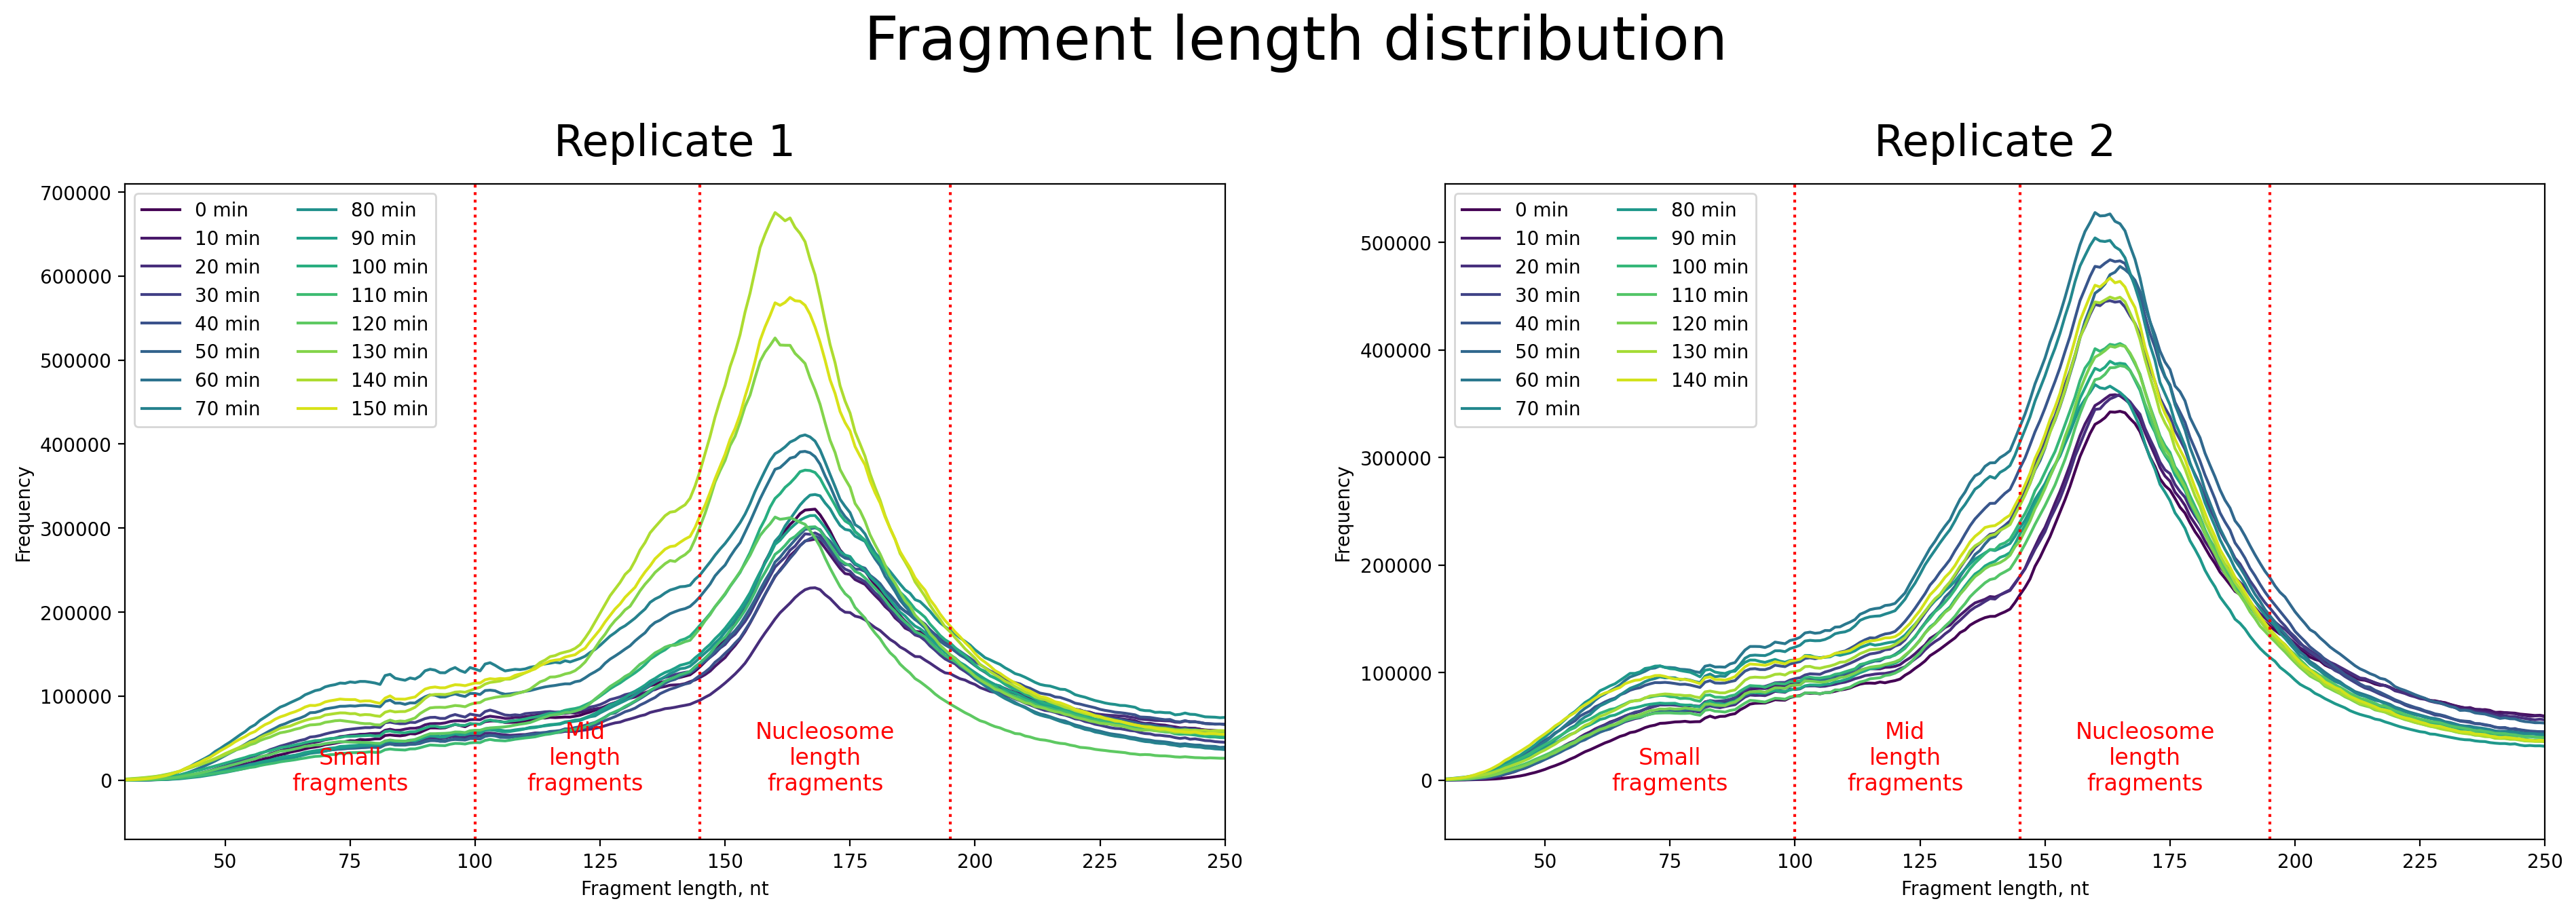

In [177]:
plot_rep_tp_counts(rep1_tp_counts, rep2_tp_counts)

In [ ]:
joined_replicate_len_counts = rep1_tp_counts.join(rep2_tp_counts, lsuffix='_replicate1', rsuffix='_replicate2')

In [404]:
joined_scaling_mat = compute_scaling_matrix(joined_replicate_len_counts)

In [406]:
jointed_rescaled_len_counts = (joined_replicate_len_counts * joined_scaling_mat)

In [432]:
joined_scaling_mat.columns

Index([  '0_replicate1',  '10_replicate1',  '20_replicate1',  '30_replicate1',
        '40_replicate1',  '50_replicate1',  '60_replicate1',  '70_replicate1',
        '80_replicate1',  '90_replicate1', '100_replicate1', '110_replicate1',
       '120_replicate1', '130_replicate1', '140_replicate1',              150,
         '0_replicate2',  '10_replicate2',  '20_replicate2',  '30_replicate2',
        '40_replicate2',  '50_replicate2',  '60_replicate2',  '70_replicate2',
        '80_replicate2',  '90_replicate2', '100_replicate2', '110_replicate2',
       '120_replicate2', '130_replicate2', '140_replicate2'],
      dtype='object')

In [433]:
# Add missing replicate 1 timepoint name
joined_scaling_mat = joined_scaling_mat.rename(columns={150: '150_replicate1'})

In [434]:
joined_scaling_mat.columns

Index(['0_replicate1', '10_replicate1', '20_replicate1', '30_replicate1',
       '40_replicate1', '50_replicate1', '60_replicate1', '70_replicate1',
       '80_replicate1', '90_replicate1', '100_replicate1', '110_replicate1',
       '120_replicate1', '130_replicate1', '140_replicate1', '150_replicate1',
       '0_replicate2', '10_replicate2', '20_replicate2', '30_replicate2',
       '40_replicate2', '50_replicate2', '60_replicate2', '70_replicate2',
       '80_replicate2', '90_replicate2', '100_replicate2', '110_replicate2',
       '120_replicate2', '130_replicate2', '140_replicate2'],
      dtype='object')

In [435]:
joined_scaling_mat.index.name = 'length'

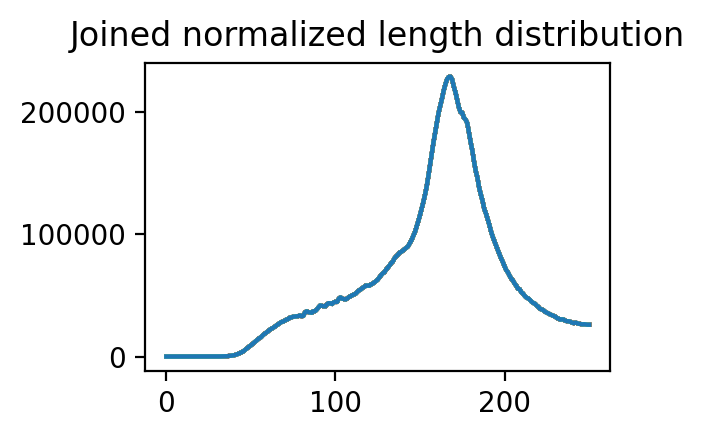

In [436]:
plt.figure(figsize=(3, 2))
plt.plot(jointed_rescaled_len_counts)
plt.title("Joined normalized length distribution")

joined_scaling_mat.to_csv('datasets/computed_mnase/combined_len_scaling.csv')

In [194]:
rep1_len_scaling_matrix = compute_scaling_matrix(rep1_tp_counts)
rep2_len_scaling_matrix = compute_scaling_matrix(rep2_tp_counts)

normalized1 = rep1_tp_counts * rep1_len_scaling_matrix
normalized2 = rep2_tp_counts * rep2_len_scaling_matrix

# Between the two replicates, the second replicate has almost twice as many reads
# so we need to scale the second replicates scaling factor down
rep_norm = normalized1[0].sum() / normalized2[0].sum()
rep2_len_scaling_matrix = rep2_len_scaling_matrix * rep_norm

rep1_len_scaling_matrix.to_csv('output/mnase/rep1_len_scaling.csv')
rep2_len_scaling_matrix.to_csv('output/mnase/rep2_len_scaling.csv')


In [195]:
normalized1 = rep1_tp_counts * rep1_len_scaling_matrix
normalized2 = rep2_tp_counts * rep2_len_scaling_matrix

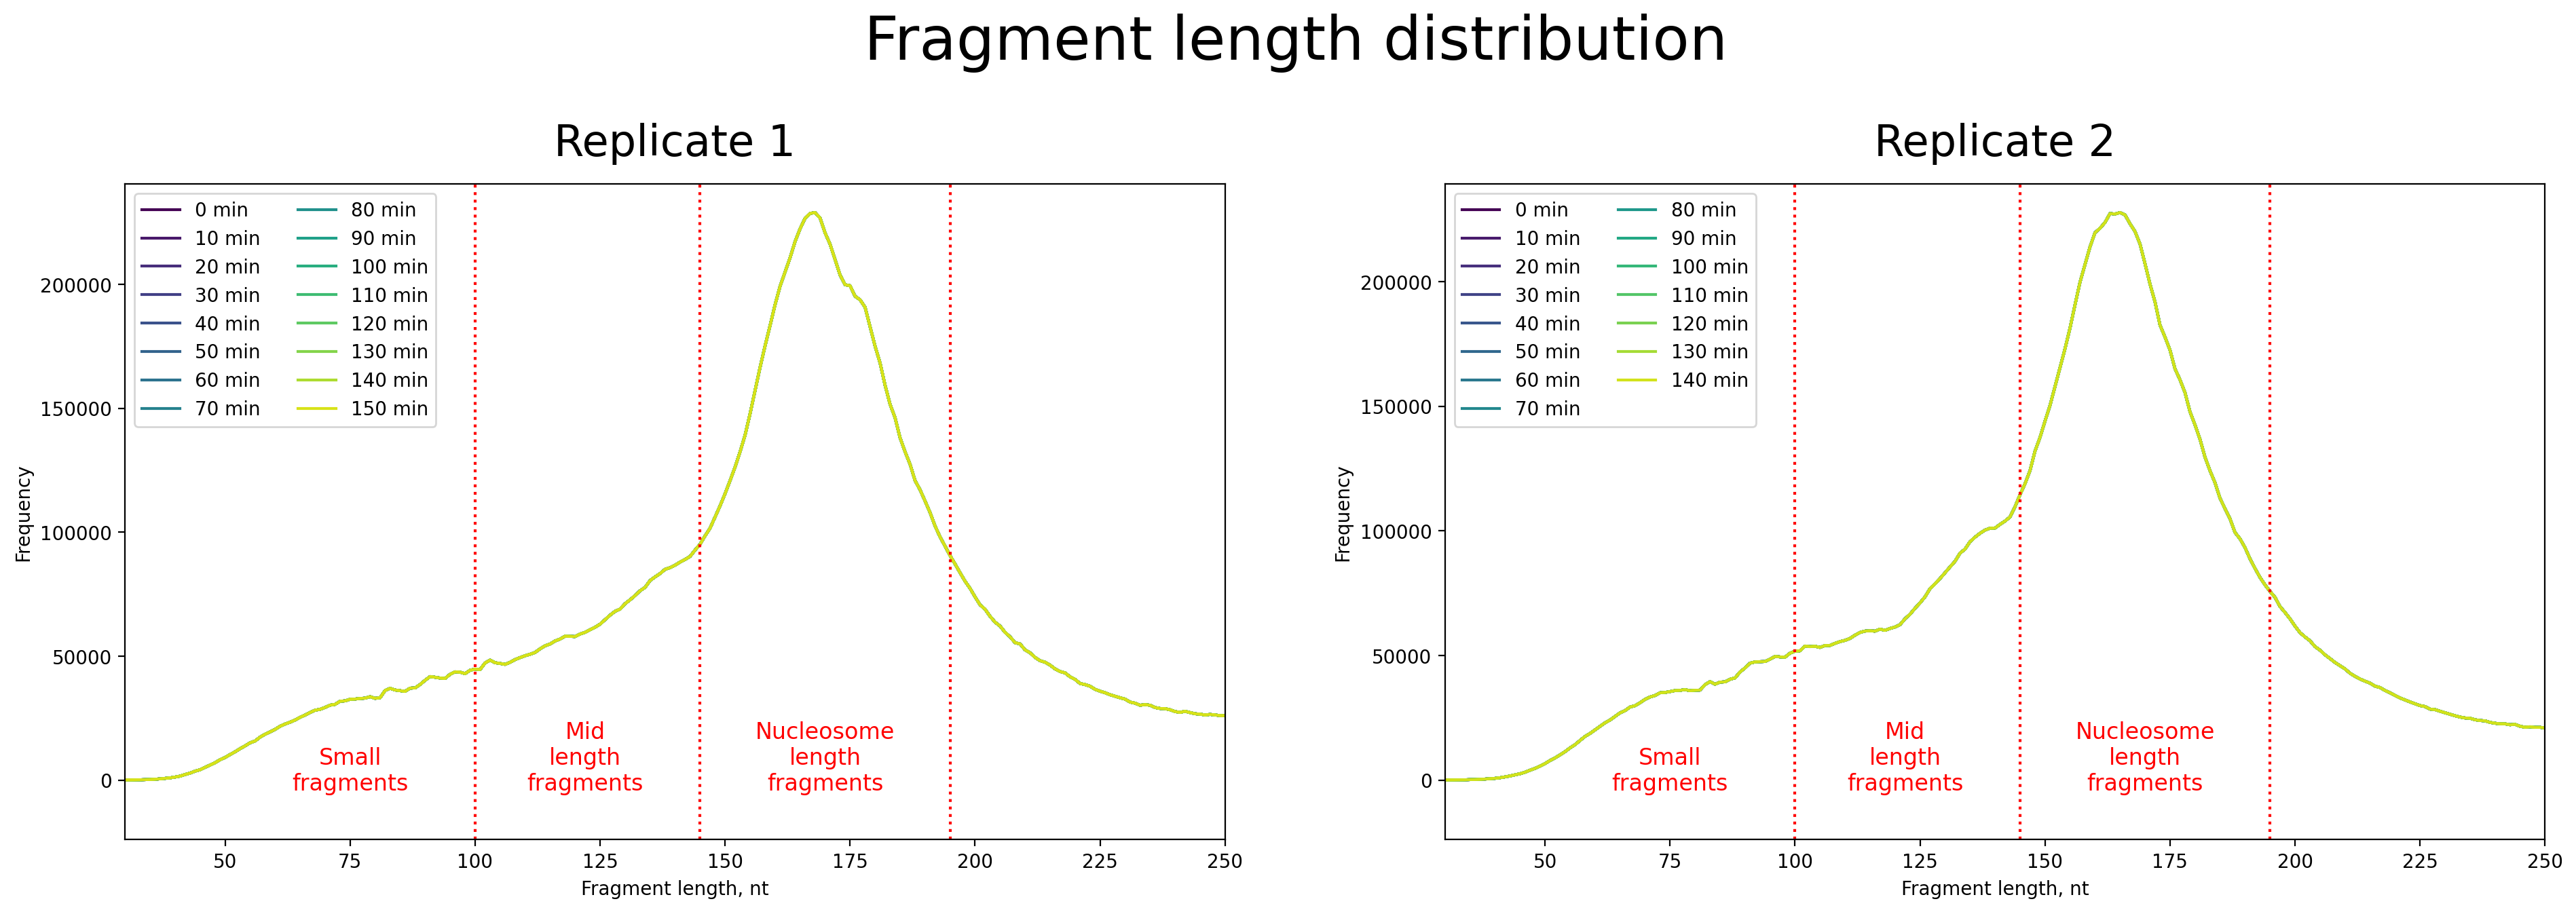

In [196]:
plot_rep_tp_counts(normalized1, normalized2)

Text(0.5, 1.0, 'Normalized length distributions')

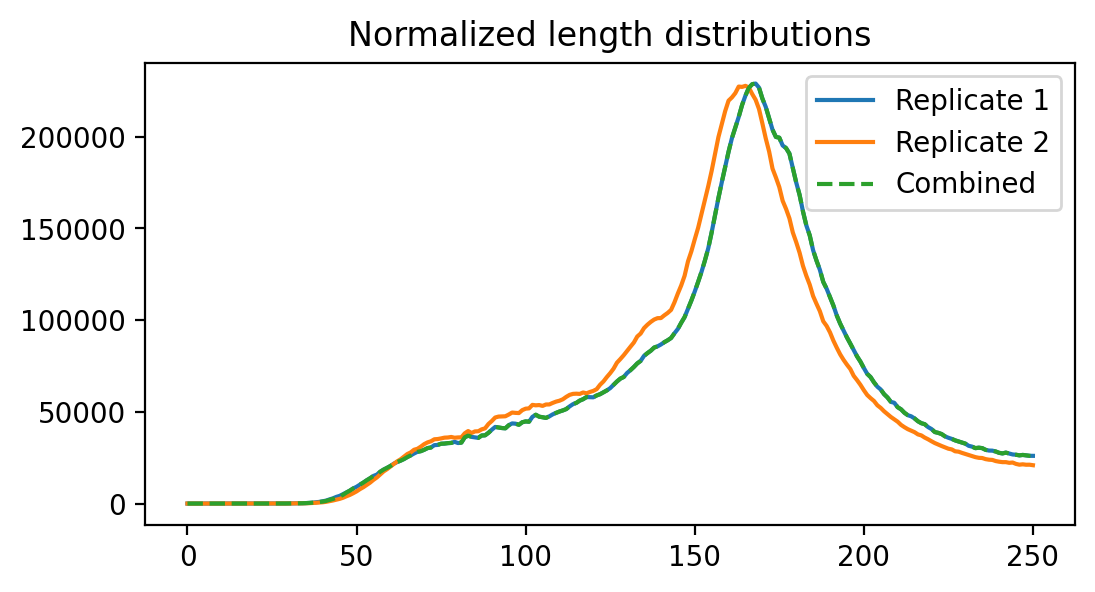

In [414]:
# The length distributions are similar enough between the two that we don't need to apply
# the per sample min length procedure on the replicates
plt.figure(figsize=(6, 3))
plt.plot(normalized1[0], label='Replicate 1')
plt.plot(normalized2[0], label='Replicate 2')
plt.plot(jointed_rescaled_len_counts['0_replicate1'], label='Combined', linestyle='dashed')
plt.legend()
plt.title('Normalized length distributions')


In [417]:
# Because we will be creating a grid of our chromatin windows, we will want to scale bins
# of the length distribution, particularly the small, mid, and nucleosome-length fragments
# So let's make scaling matrix for those subsets of lengths as well
joined_subset_scaling_mat = convert_scaling_matrix_to_len_bins(joined_scaling_mat)
joined_subset_scaling_mat.to_csv('datasets/computed_mnase/joined_len_scaling_3len_bins.csv')


In [416]:
joined_subset_scaling_mat.head(2)

,"(0, 100)","(100, 145)","(145, 195)"
0_replicate1,0.462766,0.722742,0.702182
10_replicate1,0.439021,0.711941,0.772832


In [418]:
# Because we will be creating a grid of our chromatin windows, we will want to scale bins
# of the length distribution, particularly the small, mid, and nucleosome-length fragments
# So let's make scaling matrix for those subsets of lengths as well
rep1_subset_scaling_mat = convert_scaling_matrix_to_len_bins(rep1_len_scaling_matrix)
rep2_subset_scaling_mat = convert_scaling_matrix_to_len_bins(rep2_len_scaling_matrix)

rep2_subset_scaling_mat.head(2)

rep1_subset_scaling_mat.to_csv('datasets/computed_mnase/rep1_len_scaling_3len_bins.csv')
rep2_subset_scaling_mat.to_csv('datasets/computed_mnase/rep2_len_scaling_3len_bins.csv')

In [216]:
rep1_subset_scaling_mat.head(2)

,"(0, 100)","(100, 145)","(145, 195)"
0,0.468794,0.722742,0.702182
10,0.444653,0.711941,0.772832
